In [3]:
import torch
import h5py
import numpy as np
import matplotlib.pyplot as plt
import argparse

import sys
from pathlib import Path
# Ensure local 'src' is on sys.path so we can import lcgen
proj_root = Path.cwd().parent  
sys.path.insert(0, str(proj_root / "src"))
from lcgen.models.simple_min_gru import SimpleMinGRU
from pathlib import Path
from lcgen.utils.trunc_data import extract_data
from lcgen.utils.loss import recon_loss
from torch.utils.data import DataLoader
from lcgen.models.simple_min_gru import SimpleMinGRU
from lcgen.train_simple_rnn import TimeSeriesDataset, collate_fn

### Setup

In [7]:
random_seed = 19
model_path = Path('../output/simple_rnn/simple_min_gru_final.pt')
hidden_size = 64
use_flow = False
num_examples = 3
seq_length = 1024

### Munge data

In [9]:

torch.manual_seed(random_seed)
np.random.seed(random_seed)

# Create folder for plots
outp = Path(model_path).parent / 'recon_plots'
outp.mkdir(parents=True, exist_ok=True)

# Load model
model = SimpleMinGRU(hidden_size=hidden_size, use_flow=use_flow)
model.load_state_dict(torch.load(model_path)['model_state_dict'])
model.eval()
print('Loaded model from ', model_path)

# Load data and generate reconstructions
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
raw_data_path = Path('../data/timeseries.h5')
ds = TimeSeriesDataset(raw_data_path, random_seed=random_seed, max_length=seq_length, num_samples=num_examples)
loader = DataLoader(ds, batch_size=num_examples, shuffle=False, collate_fn=collate_fn)
batch_X = next(iter(loader)) 
flux, flux_err, times = batch_X
flux = flux.to(device)
flux_err = flux_err.to(device)
times = times.to(device)

# Build input channels [flux, flux_err] -> (B, L, 2)
x_in = torch.stack([flux, flux_err], dim=-1)

out = model(x_in)
recon = out['reconstructed']  # (B, L, 1) -> [mean, raw_logsigma]
mean = recon[..., 0]
loss = recon_loss(flux, flux_err, mean)
flux_np = flux.cpu().numpy()
flux_err_np = flux_err.cpu().numpy()
times_np = times.cpu().numpy()
mean_np = mean.detach().cpu().numpy()
loss_np = loss.detach().cpu().numpy()


Loaded model from  ../output/simple_rnn/simple_min_gru_final.pt
Truncated data to max_length=1024, kept 3/7911 samples.


### Plot entire sequences

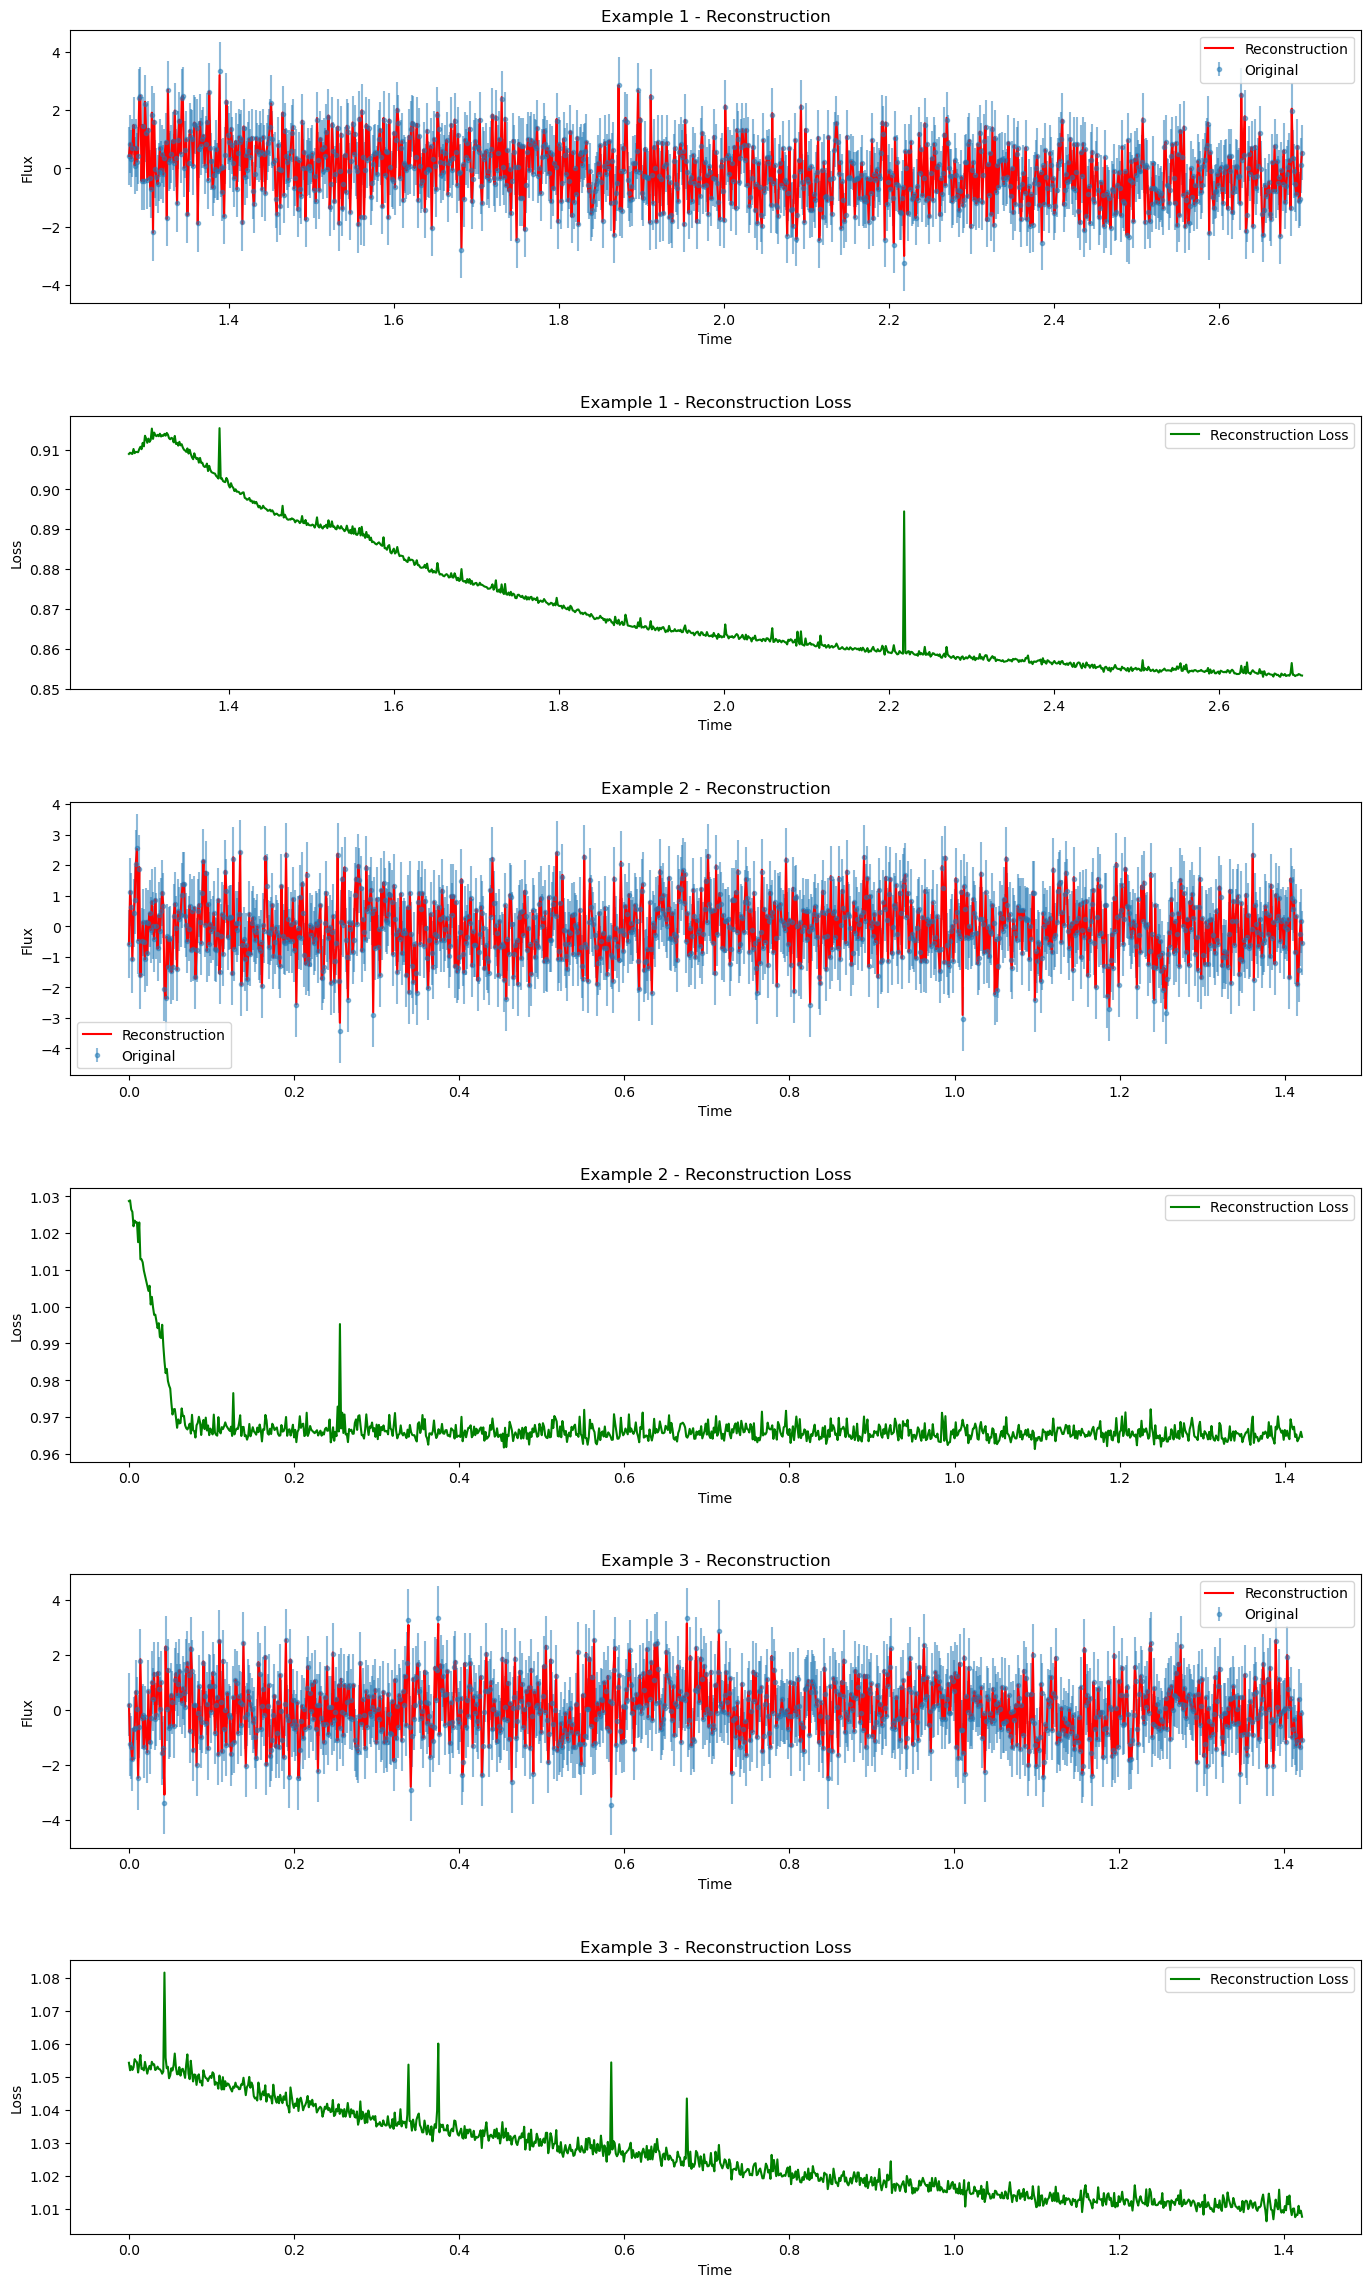

In [10]:
fig, ax = plt.subplots(num_examples*2,1,figsize=(15, num_examples * 8))
plt.tight_layout(pad=6.0)

for i in range(num_examples):

    # Reconstruction
    plt.subplot(num_examples*2,1,(i*2)+1)
    plt.errorbar(times_np[i], flux_np[i], yerr=flux_err_np[i], fmt='.', label='Original', alpha=0.5)
    plt.plot(times_np[i], mean_np[i], label='Reconstruction', color='red')
    plt.title(f'Example {i+1} - Reconstruction')
    plt.xlabel('Time')
    plt.ylabel('Flux')
    plt.legend()

    # Loss
    plt.subplot(num_examples*2,1,(i*2)+2)
    plt.plot(times_np[i], loss_np[i], label='Reconstruction Loss', color='green')
    plt.title(f'Example {i+1} - Reconstruction Loss')
    plt.xlabel('Time')
    plt.ylabel('Loss')
    plt.legend()

plt.show()

### Plot subsequences

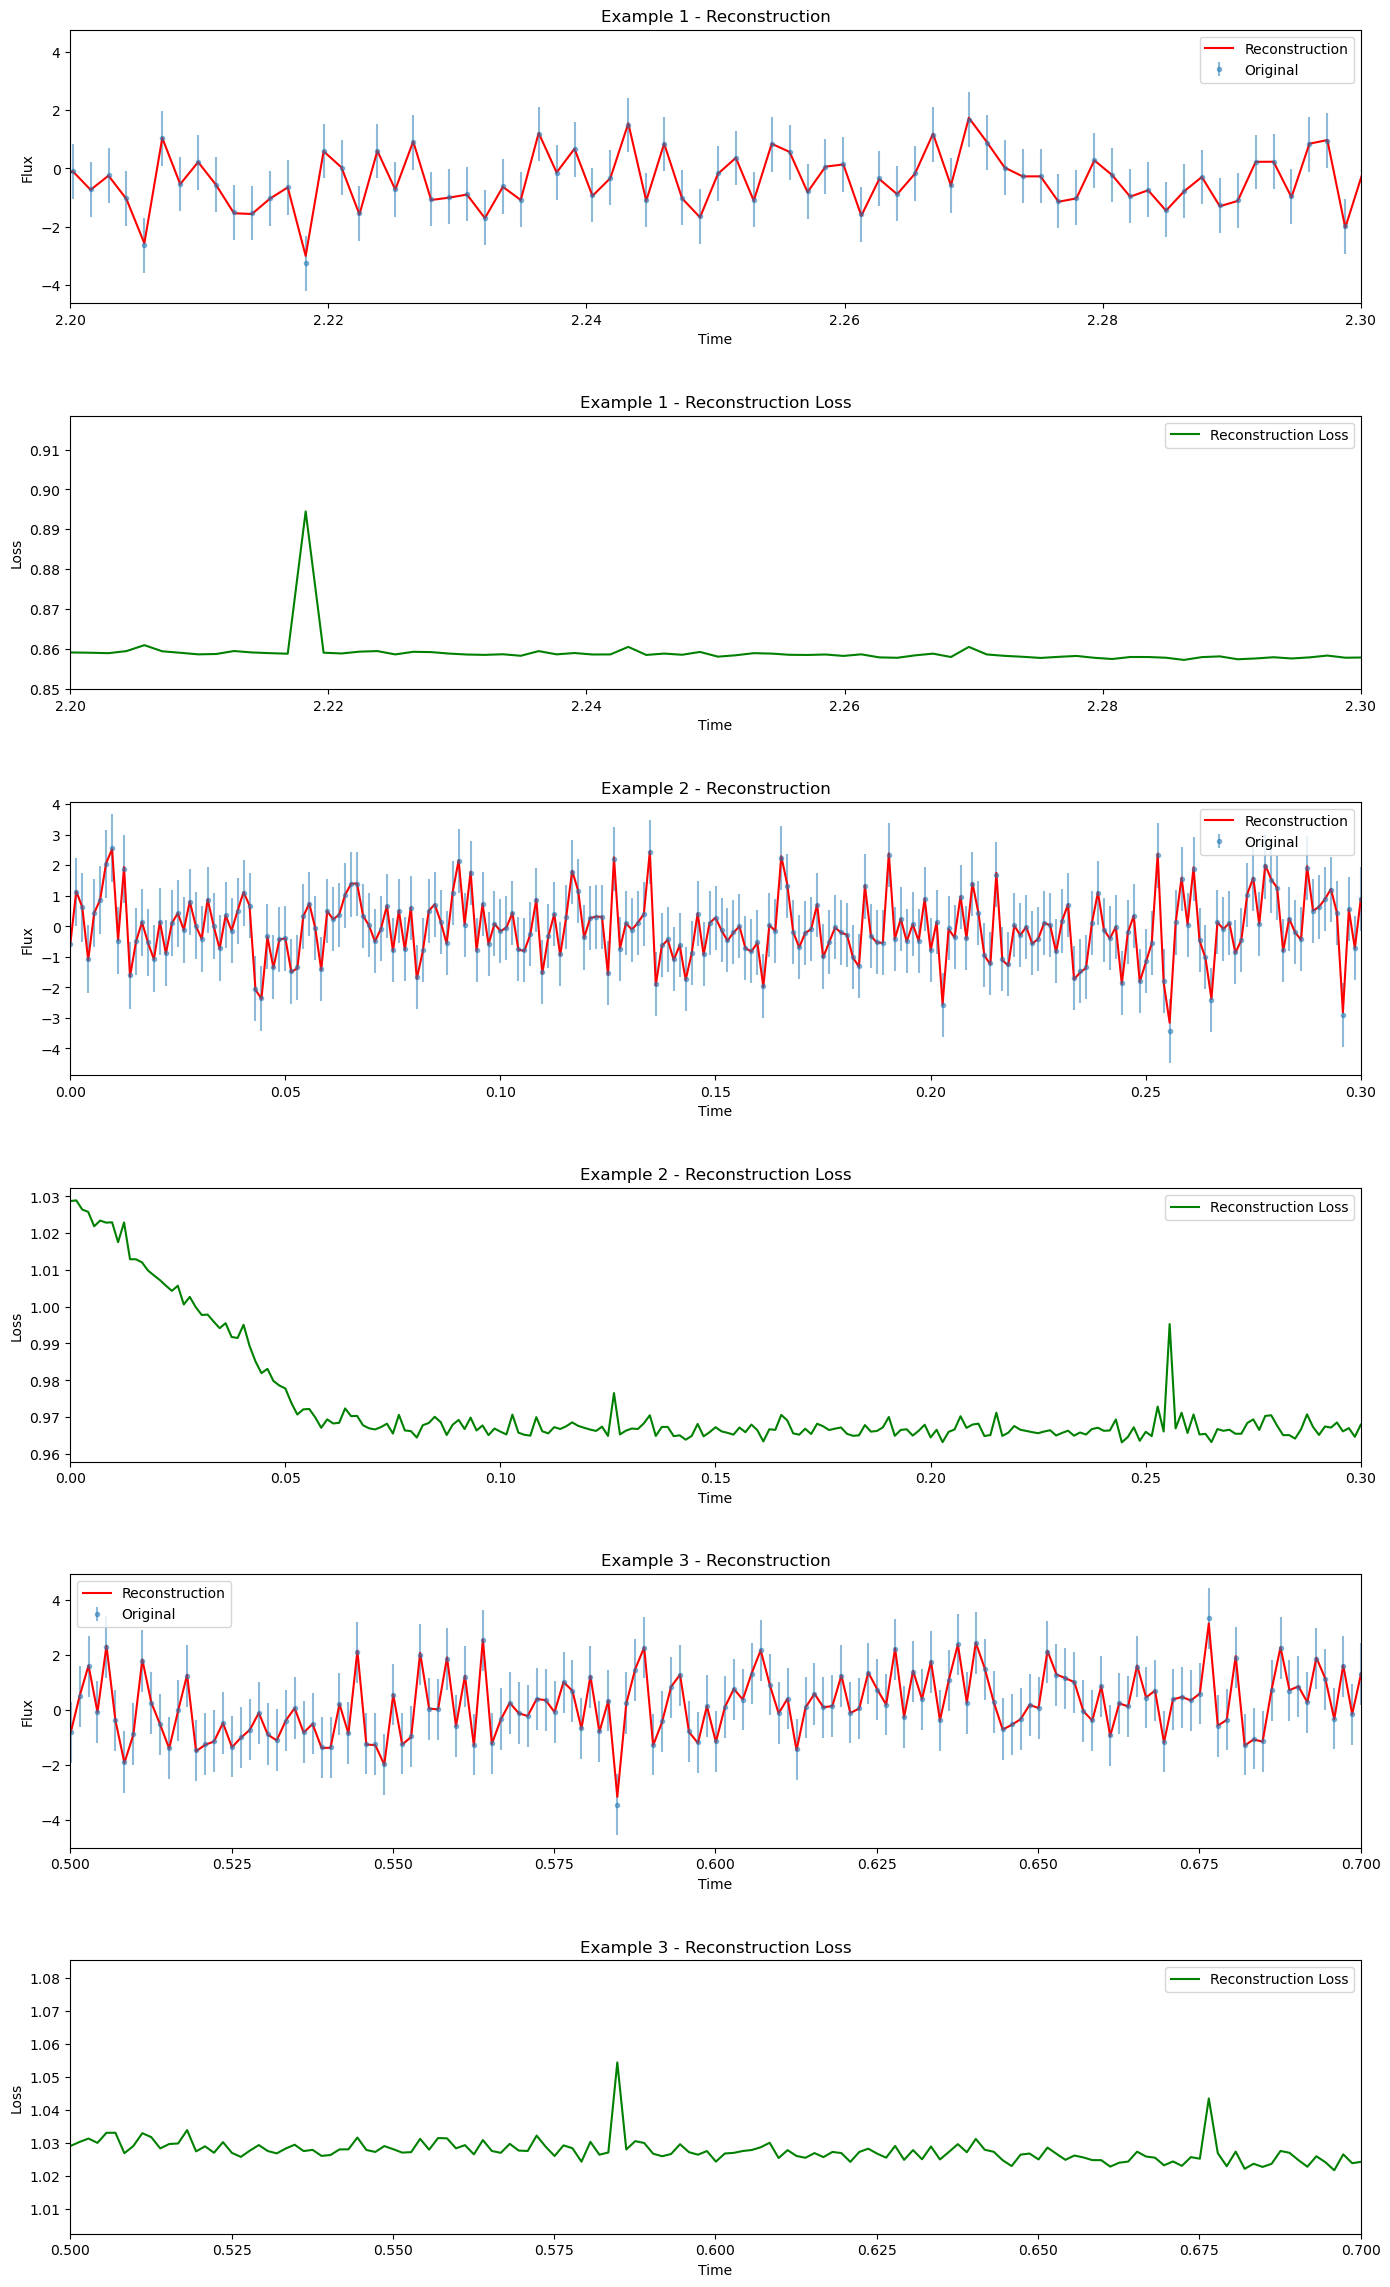

In [12]:
zoom_times = [
    (2.2, 2.3),
    (0, 0.3),
    (0.5, 0.7)
]

fig, ax = plt.subplots(num_examples*2,1,figsize=(15, num_examples * 8))
plt.tight_layout(pad=6.0)

for i in range(num_examples):

    # Reconstruction
    plt.subplot(num_examples*2,1,(i*2)+1)
    plt.errorbar(times_np[i], flux_np[i], yerr=flux_err_np[i], fmt='.', label='Original', alpha=0.5)
    plt.plot(times_np[i], mean_np[i], label='Reconstruction', color='red')
    plt.title(f'Example {i+1} - Reconstruction')
    plt.xlabel('Time')
    plt.ylabel('Flux')
    plt.xlim(zoom_times[i])
    plt.legend()

    # Loss
    plt.subplot(num_examples*2,1,(i*2)+2)
    plt.plot(times_np[i], loss_np[i], label='Reconstruction Loss', color='green')
    plt.title(f'Example {i+1} - Reconstruction Loss')
    plt.xlabel('Time')
    plt.ylabel('Loss')
    plt.xlim(zoom_times[i])
    plt.legend()

plt.show()